In [15]:
import numpy as np
import matplotlib.pyplot as plt
from time import perf_counter
from multiprocessing import Pool, cpu_count
import os

print(f'Version de numpy: {np.__version__}')
print(f'Cpus visibles para Python: {cpu_count()}')

Version de numpy: 2.0.2
Cpus visibles para Python: 2


In [16]:
def orbita_mandelbrot(c, nmax=10):
    z = 0 + 0j
    datos = []

    for n in range(nmax):
        datos.append((n, z, abs(z)))
        z = z**2 + c

    datos.append((nmax, z, abs(z)))

    return datos

In [17]:
c = -0.75 + 0.1j
datos = orbita_mandelbrot(c, 15)

print(f'Órbita para c = {c}')
for n, z, r in datos:
    print(f'n = {n:2d}     z={z.real:+.4f}{z.imag:+.4f}j      |z|={r:.6f}')

Órbita para c = (-0.75+0.1j)
n =  0     z=+0.0000+0.0000j      |z|=0.000000
n =  1     z=-0.7500+0.1000j      |z|=0.756637
n =  2     z=-0.1975-0.0500j      |z|=0.203731
n =  3     z=-0.7135+0.1198j      |z|=0.723473
n =  4     z=-0.2553-0.0709j      |z|=0.264925
n =  5     z=-0.6899+0.1362j      |z|=0.703177
n =  6     z=-0.2926-0.0879j      |z|=0.305553
n =  7     z=-0.6721+0.1514j      |z|=0.688943
n =  8     z=-0.3212-0.1036j      |z|=0.337514
n =  9     z=-0.6575+0.1665j      |z|=0.678301
n = 10     z=-0.3454-0.1190j      |z|=0.365309
n = 11     z=-0.6449+0.1822j      |z|=0.670125
n = 12     z=-0.3673-0.1350j      |z|=0.391357
n = 13     z=-0.6333+0.1992j      |z|=0.663878
n = 14     z=-0.3886-0.1523j      |z|=0.417387
n = 15     z=-0.6222+0.2184j      |z|=0.659375


In [18]:
def tiempo_escape(c, nmax=100):
    z = 0 + 0j
    for n in range(nmax):
        z = z**2 + c
        if abs(z) > 2:
            return n + 1
    return nmax

In [19]:
pruebas = [0 + 0j, 1 + 0j, -1 + 0j, -0.75 + 0.1j, 0.3 + 0.5j]

for c in pruebas:
    print(f'c={c:>12}   -> escape={tiempo_escape(c, 100)}')

c=          0j   -> escape=100
c=      (1+0j)   -> escape=3
c=     (-1+0j)   -> escape=100
c=(-0.75+0.1j)   -> escape=33
c=  (0.3+0.5j)   -> escape=100


In [20]:
#Region del set mandelbrot
xmin, xmax = -2.2, 1.0
ymin, ymax = -1.4, 1.4

ancho = 8
alto = 6

xs = np.linspace(xmin, xmax, ancho)
ys = np.linspace(ymin, ymax, alto)

print(f'xs = {xs}')
print(f'ys = {ys}')

xs = [-2.2        -1.74285714 -1.28571429 -0.82857143 -0.37142857  0.08571429
  0.54285714  1.        ]
ys = [-1.4  -0.84 -0.28  0.28  0.84  1.4 ]


In [21]:
#Ahora una rejilla para ver que significa cada pixel
X, Y = np.meshgrid(xs, ys)

C = X + 1j*Y

print(f'{X.shape}')
print(f'{Y.shape}')
print(f'{C.shape}')

print(np.round(C, 1))

(6, 8)
(6, 8)
(6, 8)
[[-2.2-1.4j -1.7-1.4j -1.3-1.4j -0.8-1.4j -0.4-1.4j  0.1-1.4j  0.5-1.4j
   1. -1.4j]
 [-2.2-0.8j -1.7-0.8j -1.3-0.8j -0.8-0.8j -0.4-0.8j  0.1-0.8j  0.5-0.8j
   1. -0.8j]
 [-2.2-0.3j -1.7-0.3j -1.3-0.3j -0.8-0.3j -0.4-0.3j  0.1-0.3j  0.5-0.3j
   1. -0.3j]
 [-2.2+0.3j -1.7+0.3j -1.3+0.3j -0.8+0.3j -0.4+0.3j  0.1+0.3j  0.5+0.3j
   1. +0.3j]
 [-2.2+0.8j -1.7+0.8j -1.3+0.8j -0.8+0.8j -0.4+0.8j  0.1+0.8j  0.5+0.8j
   1. +0.8j]
 [-2.2+1.4j -1.7+1.4j -1.3+1.4j -0.8+1.4j -0.4+1.4j  0.1+1.4j  0.5+1.4j
   1. +1.4j]]


In [22]:
def mandelbrot_naive(xmin, xmax, ymin, ymax, ancho=400, alto=300, nmax=100):
    xs = np.linspace(xmin, xmax, ancho)
    ys = np.linspace(ymin, ymax, alto)

    img = np.zeros((alto, ancho), dtype=np.int32)

    for i, y in enumerate(ys):
        for j, x in enumerate(xs):
            c = x + 1j*y
            z = 0 + 0j

            for n in range(nmax):
                z = z**2 + c
                if abs(z) > 2:
                    img[i, j] = n + 1
                    break
            else:
                img[i, j] = nmax
    return img

Tiempo naive: 6.278 s


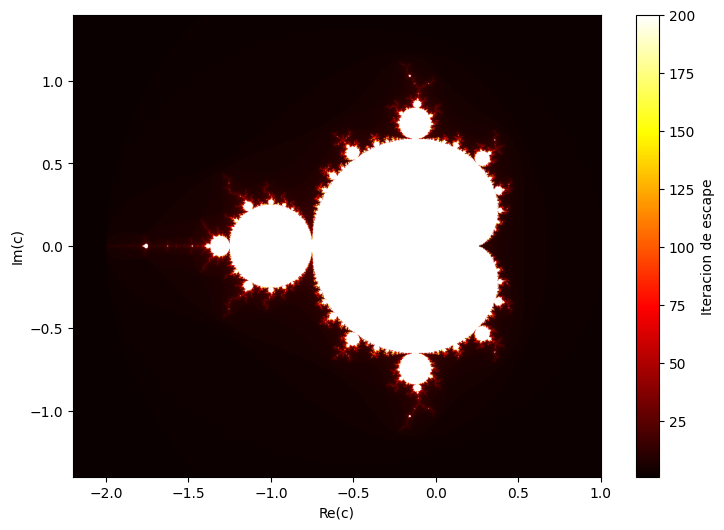

In [23]:
t0 = perf_counter()
img_naive = mandelbrot_naive(-2.2, 1.0, -1.4, 1.4, ancho=1000, alto=700, nmax=200)
t1 = perf_counter()

print(f'Tiempo naive: {t1 - t0:.3f} s')

plt.figure(figsize=(9, 6))
plt.imshow(img_naive, extent=[-2.2, 1.0, -1.4, 1.4], cmap='hot')
plt.colorbar(label="Iteracion de escape")
plt.xlabel("Re(c)")
plt.ylabel("Im(c)")
plt.show()

In [24]:
def mandelbrot_vectorizado(xmin, xmax, ymin, ymax, ancho=400, alto=300, nmax=200):
    xs = np.linspace(xmin, xmax, ancho)
    ys = np.linspace(ymin, ymax, alto)
    X, Y = np.meshgrid(xs, ys)
    C = X + 1j*Y

    #para cada uno de estos complejos, hacemos un Z0
    Z = np.zeros_like(C, dtype=np.complex128)
    img = np.full(C.shape, nmax, dtype=np.int32)
    activos = np.ones(C.shape, dtype=bool)   #True donde todavía no escapó

    for n in range(nmax):
        Z[activos] = Z[activos]**2 + C[activos]

        escaparon_ahora = (np.abs(Z) > 2) & activos
        img[escaparon_ahora] = n + 1
        activos[escaparon_ahora] = False

        if not np.any(activos):
            break
    return img


Tiempo vectorizado: 0.874 s


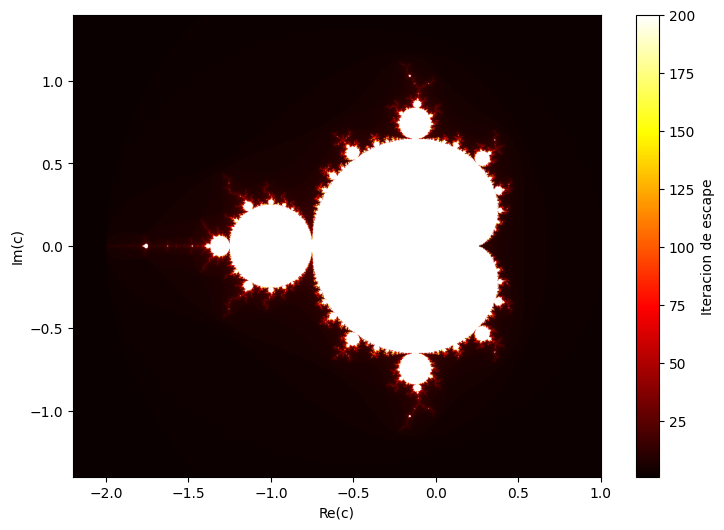

In [25]:
t0 = perf_counter()
img_naive = mandelbrot_vectorizado(-2.2, 1.0, -1.4, 1.4, ancho=1000, alto=700, nmax=200)
t1 = perf_counter()

print(f'Tiempo vectorizado: {t1 - t0:.3f} s')

plt.figure(figsize=(9, 6))
plt.imshow(img_naive, extent=[-2.2, 1.0, -1.4, 1.4], cmap='hot')
plt.colorbar(label="Iteracion de escape")
plt.xlabel("Re(c)")
plt.ylabel("Im(c)")
plt.show()

In [29]:
def benchmark(func, tamaños, nmax=100):
    resultados = []
    for ancho, alto in tamaños:
        t0 = perf_counter()
        _ = func(-2.2, 1.0, -1.4, 1.4, ancho=ancho, alto=alto, nmax=nmax)
        t1 = perf_counter()
        resultados.append((ancho, alto, t1 - t0))
    return resultados

In [ ]:
tamaños = [(200, 150), (400, 300), (700, 500), (1000, 700), (2000, 1400), (4000, 2800), (8000, 5600)]

res_naive = benchmark(mandelbrot_naive, tamaños, nmax=300)
res_vec = benchmark(mandelbrot_vectorizado, tamaños, nmax=300)

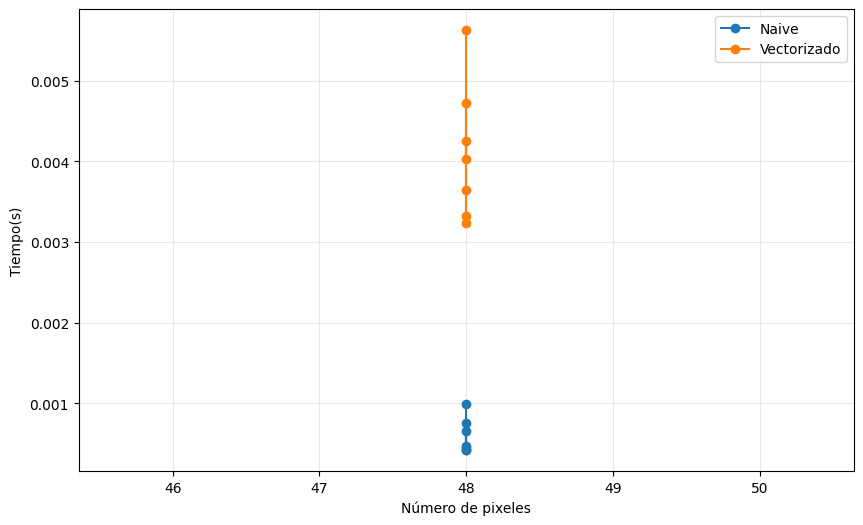

8x6 : speedup ~ 0.12x
8x6 : speedup ~ 0.13x
8x6 : speedup ~ 0.15x
8x6 : speedup ~ 0.12x
8x6 : speedup ~ 0.18x
8x6 : speedup ~ 0.10x
8x6 : speedup ~ 0.21x


In [28]:
anchos = [r[0] for r in res_naive]
pixeles = [r[0]*r[1] for r in res_naive]
t_naive = [r[2] for r in res_naive]
t_vec = [r[2] for r in res_vec]

plt.figure(figsize=(10, 6))
plt.plot(pixeles, t_naive, marker='o', label='Naive')
plt.plot(pixeles, t_vec, marker='o', label='Vectorizado')

plt.xlabel("Número de pixeles")
plt.ylabel("Tiempo(s)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

for (a, h, tn), (_, _, tv) in zip(res_naive, res_vec):
    print(f'{a}x{h} : speedup ~ {tn/tv:.2f}x')